# Avaliação Final no Conjunto de Teste

Após a análise exploratória dos dados, comparação dos algoritmos de
Machine Learning e definição da política de decisão, esta etapa realiza
a avaliação final do sistema no conjunto de teste.

O CatBoost selecionado durante a etapa experimental encontra-se
congelado e será utilizado sem qualquer novo treinamento ou ajuste de
hiperparâmetros.

Da mesma forma, a política de decisão foi previamente definida no
conjunto de validação:

- **APROVAR:** score < 0,20;
- **REVISAR:** 0,20 ≤ score < 0,90;
- **ALERTA_CRÍTICO:** score ≥ 0,90.

O conjunto de teste corresponde aos 15% temporalmente mais recentes da
base e não participou do treinamento do modelo, da seleção do algoritmo
ou da definição dos thresholds.

A partir deste momento, os resultados observados no teste serão tratados
como a avaliação final do sistema. Nenhuma alteração no modelo, nas
features ou na política de decisão será realizada com base nesses
resultados.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(
    0,
    str(PROJECT_ROOT)
)

print(
    "Project root:",
    PROJECT_ROOT
)

Project root: /Users/lucassantos/Documents/ccard_fraud_ml


In [3]:
from src.inference import FraudModel
from src.decision_policy import DecisionPolicy

In [4]:
modelo_fraude = FraudModel()
politica = DecisionPolicy()

In [5]:
print(
    "Quantidade de árvores:",
    modelo_fraude.modelo.tree_count_
)

print(
    "Threshold de revisão:",
    politica.threshold_revisao
)

print(
    "Threshold crítico:",
    politica.threshold_critico
)

Quantidade de árvores: 719
Threshold de revisão: 0.2
Threshold crítico: 0.9


In [6]:
DATA_PATH = (
    PROJECT_ROOT
    / "raw"
    / "fraudTrain.csv"
)

In [7]:
dtypes = {
    "cc_num": "string",
    "trans_num": "string",
    "zip": "string",
    "merchant": "string",
    "category": "category",
    "gender": "category",
    "state": "category",
    "first": "string",
    "last": "string",
    "street": "string",
    "city": "string",
    "job": "string"
}

In [8]:
df = pd.read_csv(
    DATA_PATH,
    dtype=dtypes,
    parse_dates=[
        "trans_date_trans_time",
        "dob"
    ]
)

In [9]:
colunas_indice = [
    coluna
    for coluna in df.columns
    if str(coluna).startswith(
        "Unnamed:"
    )
]

if colunas_indice:
    df = df.drop(
        columns=colunas_indice
    )

In [10]:
print(
    "Transações totais:",
    f"{len(df):,}"
)

print(
    "Fraudes totais:",
    f"{df['is_fraud'].sum():,}"
)

Transações totais: 1,296,675
Fraudes totais: 7,506


In [11]:
df = (
    df
    .sort_values(
        "trans_date_trans_time"
    )
    .reset_index(drop=True)
)

In [12]:
print(
    "Primeira transação:",
    df["trans_date_trans_time"].iloc[0]
)

print(
    "Última transação:",
    df["trans_date_trans_time"].iloc[-1]
)

Primeira transação: 2019-01-01 00:00:18
Última transação: 2020-06-21 12:13:37


In [13]:
n_total = len(df)

fim_treino = int(
    n_total * 0.70
)

fim_validacao = int(
    n_total * 0.85
)

In [14]:
df_treino = (
    df.iloc[
        :fim_treino
    ]
    .copy()
)

df_validacao = (
    df.iloc[
        fim_treino:fim_validacao
    ]
    .copy()
)

df_teste = (
    df.iloc[
        fim_validacao:
    ]
    .copy()
)

In [15]:
print(
    "Treino:",
    f"{len(df_treino):,}"
)

print(
    "Validação:",
    f"{len(df_validacao):,}"
)

print(
    "Teste:",
    f"{len(df_teste):,}"
)

Treino: 907,672
Validação: 194,501
Teste: 194,502


In [16]:
total_fraudes_teste = int(
    df_teste[
        "is_fraud"
    ].sum()
)

total_legitimas_teste = int(
    (
        df_teste[
            "is_fraud"
        ] == 0
    ).sum()
)

prevalencia_teste = (
    total_fraudes_teste
    / len(df_teste)
)

In [17]:
print(
    "Fraudes no teste:",
    f"{total_fraudes_teste:,}"
)

print(
    "Legítimas no teste:",
    f"{total_legitimas_teste:,}"
)

print(
    "Prevalência de fraude:",
    f"{prevalencia_teste * 100:.4f}%"
)

Fraudes no teste: 1,133
Legítimas no teste: 193,369
Prevalência de fraude: 0.5825%


In [18]:
inicio_teste = (
    df_teste[
        "trans_date_trans_time"
    ].min()
)

fim_teste = (
    df_teste[
        "trans_date_trans_time"
    ].max()
)

In [19]:
print(
    "Início do teste:",
    inicio_teste
)

print(
    "Fim do teste:",
    fim_teste
)

print(
    "Duração:",
    fim_teste - inicio_teste
)

Início do teste: 2020-04-03 17:54:44
Fim do teste: 2020-06-21 12:13:37
Duração: 78 days 18:18:53


In [20]:
fim_validacao_data = (
    df_validacao[
        "trans_date_trans_time"
    ].max()
)

print(
    "Última transação da validação:",
    fim_validacao_data
)

print(
    "Primeira transação do teste:",
    inicio_teste
)

Última transação da validação: 2020-04-03 17:53:52
Primeira transação do teste: 2020-04-03 17:54:44


In [21]:
assert len(df) == 1_296_675

assert len(df_treino) == 907_672

assert len(df_validacao) == 194_501

assert len(df_teste) == 194_502

In [24]:
assert (
    df_treino[
        "trans_date_trans_time"
    ].max()
    <=
    df_validacao[
        "trans_date_trans_time"
    ].min()
)

assert (
    df_validacao[
        "trans_date_trans_time"
    ].max()
    <=
    df_teste[
        "trans_date_trans_time"
    ].min()
)
print(
    "Split temporal final: OK"
)

Split temporal final: OK


In [23]:
y_teste = (
    df_teste[
        "is_fraud"
    ]
    .to_numpy()
)

In [25]:
from time import perf_counter

In [26]:
inicio_inferencia = perf_counter()

scores_teste = (
    modelo_fraude
    .prever_scores(
        df_teste
    )
)

tempo_inferencia = (
    perf_counter()
    - inicio_inferencia
)

In [27]:
print(
    "Scores gerados:",
    f"{len(scores_teste):,}"
)

print(
    "Tempo de inferência:",
    f"{tempo_inferencia:.4f} segundos"
)

print(
    "Menor score:",
    scores_teste.min()
)

print(
    "Maior score:",
    scores_teste.max()
)

print(
    "Score médio:",
    scores_teste.mean()
)

Scores gerados: 194,502
Tempo de inferência: 0.3205 segundos
Menor score: 8.949905306163153e-08
Maior score: 0.9999838597582997
Score médio: 0.005594392507383425


In [28]:
assert (
    len(scores_teste)
    ==
    len(df_teste)
)

assert np.isfinite(
    scores_teste
).all()

assert (
    scores_teste >= 0
).all()

assert (
    scores_teste <= 1
).all()

print(
    "Scores do conjunto de teste: OK"
)

Scores do conjunto de teste: OK


In [29]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

In [30]:
def avaliar_modelo(
    y_real,
    scores,
    threshold: float = 0.50
) -> pd.DataFrame:

    y_real = np.asarray(
        y_real
    ).ravel()

    scores = np.asarray(
        scores
    ).ravel()

    if len(y_real) != len(scores):
        raise ValueError(
            "y_real e scores precisam possuir "
            "a mesma quantidade de observações."
        )

    if not 0 <= threshold <= 1:
        raise ValueError(
            "O threshold deve estar entre 0 e 1."
        )

    if not np.isfinite(scores).all():
        raise ValueError(
            "Os scores possuem valores "
            "ausentes ou infinitos."
        )

    y_previsto = (
        scores >= threshold
    ).astype(int)

    matriz = confusion_matrix(
        y_real,
        y_previsto,
        labels=[0, 1]
    )

    tn, fp, fn, tp = matriz.ravel()

    resultado = {
        "threshold":
            float(threshold),

        "average_precision":
            average_precision_score(
                y_real,
                scores
            ),

        "roc_auc":
            roc_auc_score(
                y_real,
                scores
            ),

        "accuracy":
            accuracy_score(
                y_real,
                y_previsto
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_real,
                y_previsto
            ),

        "precision_fraude":
            precision_score(
                y_real,
                y_previsto,
                zero_division=0
            ),

        "recall_fraude":
            recall_score(
                y_real,
                y_previsto,
                zero_division=0
            ),

        "f1_fraude":
            f1_score(
                y_real,
                y_previsto,
                zero_division=0
            ),

        "verdadeiros_negativos":
            int(tn),

        "falsos_positivos":
            int(fp),

        "falsos_negativos":
            int(fn),

        "verdadeiros_positivos":
            int(tp),

        "percentual_alertado":
            y_previsto.mean()
            * 100
    }

    return pd.DataFrame(
        [resultado]
    )

In [31]:
resultado_teste_050 = (
    avaliar_modelo(
        y_real=y_teste,
        scores=scores_teste,
        threshold=0.50
    )
)

In [32]:
resultado_teste_050.T

,0
threshold,0.500000
average_precision,0.924120
roc_auc,0.997770
accuracy,0.998488
balanced_accuracy,0.891753
precision_fraude,0.947705
recall_fraude,0.783760
f1_fraude,0.857971
verdadeiros_negativos,193320.000000
falsos_positivos,49.000000


In [33]:
politica = DecisionPolicy()

In [34]:
threshold_revisao = politica.threshold_revisao
threshold_critico = politica.threshold_critico

print(
    "Threshold revisão:",
    threshold_revisao
)

print(
    "Threshold crítico:",
    threshold_critico
)

Threshold revisão: 0.2
Threshold crítico: 0.9


In [35]:
decisoes_teste = np.full(
    len(scores_teste),
    "APROVAR",
    dtype=object
)

decisoes_teste[
    scores_teste >= threshold_revisao
] = "REVISAR"

decisoes_teste[
    scores_teste >= threshold_critico
] = "ALERTA_CRITICO"

In [36]:
print(
    "Decisões geradas:",
    f"{len(decisoes_teste):,}"
)

assert (
    len(decisoes_teste)
    ==
    len(df_teste)
)

print(
    "Aplicação da política: OK"
)

Decisões geradas: 194,502
Aplicação da política: OK


In [37]:
resultado_decisoes_teste = pd.DataFrame({
    "trans_num":
        df_teste[
            "trans_num"
        ].to_numpy(),

    "trans_date_trans_time":
        df_teste[
            "trans_date_trans_time"
        ].to_numpy(),

    "is_fraud":
        y_teste,

    "score_fraude":
        scores_teste,

    "decisao":
        decisoes_teste
})

In [38]:
resultado_decisoes_teste.head()

,trans_num,trans_date_trans_time,is_fraud,score_fraude,decisao
0,b3cb6fd853393499393f26e9285d271f,2020-04-03 17:54:44,0,0.000021,APROVAR
1,590ef013c120f88c3147cf26ae7f9cfe,2020-04-03 17:54:44,1,0.994915,ALERTA_CRITICO
2,21c9bdef6b08b3628ffdf7e5d158264f,2020-04-03 17:55:17,0,0.000086,APROVAR
3,d345b61a203a96885faa1d44a5bd815e,2020-04-03 17:55:35,0,0.000001,APROVAR
4,3d915c4e7c38d6ce14102421a4ce2d3c,2020-04-03 17:55:41,0,0.000299,APROVAR


In [39]:
def avaliar_faixas_decisao(
    y_real,
    decisoes
):

    y_real = np.asarray(
        y_real,
        dtype=int
    )

    decisoes = np.asarray(
        decisoes
    )

    resultados = []

    for decisao in [
        "APROVAR",
        "REVISAR",
        "ALERTA_CRITICO"
    ]:

        mascara = (
            decisoes == decisao
        )

        quantidade = int(
            mascara.sum()
        )

        fraudes = int(
            y_real[
                mascara
            ].sum()
        )

        legitimas = (
            quantidade
            - fraudes
        )

        taxa_fraude = (
            fraudes
            / quantidade
            if quantidade > 0
            else 0
        )

        percentual_base = (
            quantidade
            / len(y_real)
            * 100
        )

        resultados.append({
            "decisao":
                decisao,

            "quantidade":
                quantidade,

            "percentual_base":
                percentual_base,

            "fraudes":
                fraudes,

            "legitimas":
                legitimas,

            "taxa_fraude":
                taxa_fraude
        })

    return pd.DataFrame(
        resultados
    )

In [40]:
resultado_faixas_teste = (
    avaliar_faixas_decisao(
        y_real=y_teste,
        decisoes=decisoes_teste
    )
)

In [41]:
resultado_faixas_teste

,decisao,quantidade,percentual_base,fraudes,legitimas,taxa_fraude
0,APROVAR,193425,99.446278,179,193246,0.000925
1,REVISAR,338,0.173777,222,116,0.656805
2,ALERTA_CRITICO,739,0.379945,732,7,0.990528


In [42]:
linha_aprovar = (
    resultado_faixas_teste
    .loc[
        resultado_faixas_teste[
            "decisao"
        ] == "APROVAR"
    ]
    .iloc[0]
)

linha_revisar = (
    resultado_faixas_teste
    .loc[
        resultado_faixas_teste[
            "decisao"
        ] == "REVISAR"
    ]
    .iloc[0]
)

linha_critico = (
    resultado_faixas_teste
    .loc[
        resultado_faixas_teste[
            "decisao"
        ] == "ALERTA_CRITICO"
    ]
    .iloc[0]
)

In [43]:
fraudes_detectadas = int(
    linha_revisar["fraudes"]
    +
    linha_critico["fraudes"]
)

In [44]:
fraudes_perdidas = int(
    linha_aprovar["fraudes"]
)

In [45]:
recall_politica = (
    fraudes_detectadas
    /
    total_fraudes_teste
)

In [46]:
total_encaminhado = int(
    linha_revisar["quantidade"]
    +
    linha_critico["quantidade"]
)

In [47]:
percentual_encaminhado = (
    total_encaminhado
    /
    len(df_teste)
    *
    100
)

In [48]:
precision_encaminhamento = (
    fraudes_detectadas
    /
    total_encaminhado
)

In [49]:
print(
    "Fraudes totais:",
    f"{total_fraudes_teste:,}"
)

print(
    "Fraudes detectadas:",
    f"{fraudes_detectadas:,}"
)

print(
    "Fraudes perdidas:",
    f"{fraudes_perdidas:,}"
)

print(
    "Recall global da política:",
    f"{recall_politica:.4%}"
)

print()

print(
    "Transações encaminhadas:",
    f"{total_encaminhado:,}"
)

print(
    "Percentual encaminhado:",
    f"{percentual_encaminhado:.4f}%"
)

print(
    "Precisão do encaminhamento:",
    f"{precision_encaminhamento:.4%}"
)

Fraudes totais: 1,133
Fraudes detectadas: 954
Fraudes perdidas: 179
Recall global da política: 84.2012%

Transações encaminhadas: 1,077
Percentual encaminhado: 0.5537%
Precisão do encaminhamento: 88.5794%


In [50]:
print("REVISAR")

print(
    "Quantidade:",
    int(
        linha_revisar[
            "quantidade"
        ]
    )
)

print(
    "Fraudes:",
    int(
        linha_revisar[
            "fraudes"
        ]
    )
)

print(
    "Legítimas:",
    int(
        linha_revisar[
            "legitimas"
        ]
    )
)

print(
    "Taxa de fraude:",
    f"{linha_revisar['taxa_fraude']:.4%}"
)

REVISAR
Quantidade: 338
Fraudes: 222
Legítimas: 116
Taxa de fraude: 65.6805%


In [51]:
print("ALERTA_CRÍTICO")

print(
    "Quantidade:",
    int(
        linha_critico[
            "quantidade"
        ]
    )
)

print(
    "Fraudes:",
    int(
        linha_critico[
            "fraudes"
        ]
    )
)

print(
    "Legítimas:",
    int(
        linha_critico[
            "legitimas"
        ]
    )
)

print(
    "Taxa de fraude:",
    f"{linha_critico['taxa_fraude']:.4%}"
)

ALERTA_CRÍTICO
Quantidade: 739
Fraudes: 732
Legítimas: 7
Taxa de fraude: 99.0528%


In [52]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix
)

In [53]:
PASTA_FIGURAS = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "07_avaliacao_final"
)

PASTA_FIGURAS.mkdir(
    parents=True,
    exist_ok=True
)

In [54]:
def salvar_figura(
    fig,
    nome_arquivo
):

    caminho = (
        PASTA_FIGURAS
        / f"{nome_arquivo}.png"
    )

    fig.tight_layout()

    fig.savefig(
        caminho,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(
        "Figura salva em:",
        caminho.resolve()
    )

In [55]:
threshold_referencia = 0.50

y_previsto_teste_050 = (
    scores_teste
    >= threshold_referencia
).astype(int)

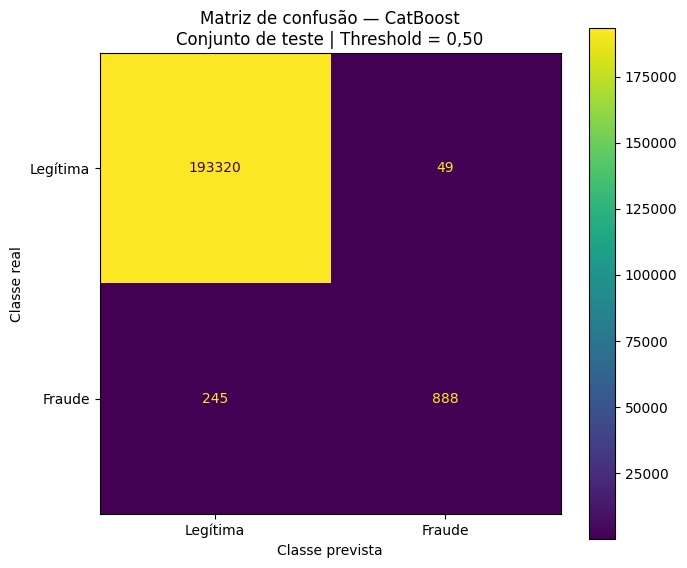

Figura salva em: /Users/lucassantos/Documents/ccard_fraud_ml/outputs/figures/07_avaliacao_final/01_matriz_confusao_teste.png


In [56]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_true=y_teste,
    y_pred=y_previsto_teste_050,
    display_labels=[
        "Legítima",
        "Fraude"
    ],
    values_format="d",
    ax=ax
)

ax.set_title(
    "Matriz de confusão — CatBoost\n"
    "Conjunto de teste | Threshold = 0,50"
)

ax.set_xlabel(
    "Classe prevista"
)

ax.set_ylabel(
    "Classe real"
)

salvar_figura(
    fig,
    "01_matriz_confusao_teste"
)

In [57]:
ordem_decisoes = [
    "APROVAR",
    "REVISAR",
    "ALERTA_CRITICO"
]

dados_taxa_decisao = (
    resultado_faixas_teste
    .set_index("decisao")
    .loc[ordem_decisoes]
    .reset_index()
    .copy()
)

dados_taxa_decisao[
    "taxa_fraude_percentual"
] = (
    dados_taxa_decisao[
        "taxa_fraude"
    ]
    * 100
)

dados_taxa_decisao

,decisao,quantidade,percentual_base,fraudes,legitimas,taxa_fraude,taxa_fraude_percentual
0,APROVAR,193425,99.446278,179,193246,0.000925,0.092542
1,REVISAR,338,0.173777,222,116,0.656805,65.680473
2,ALERTA_CRITICO,739,0.379945,732,7,0.990528,99.052774


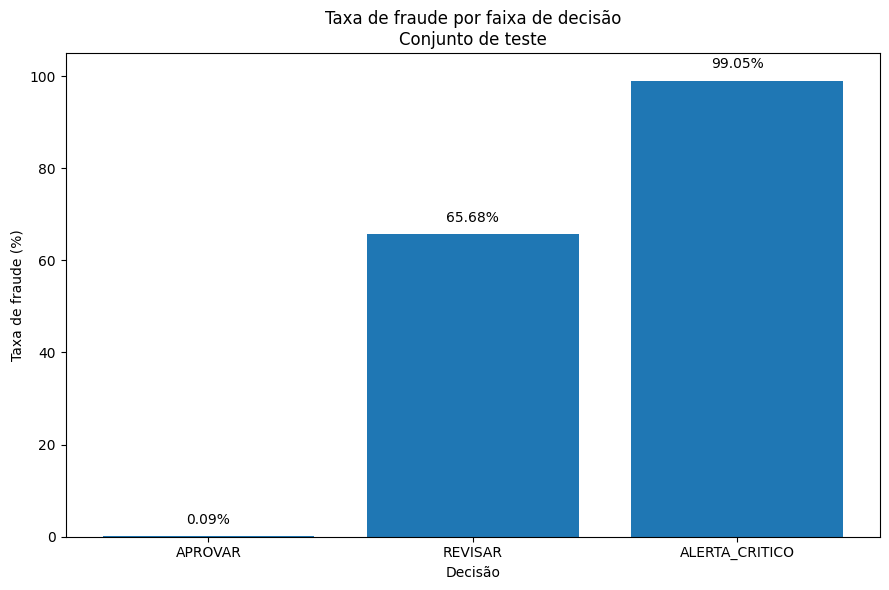

Figura salva em: /Users/lucassantos/Documents/ccard_fraud_ml/outputs/figures/07_avaliacao_final/02_taxa_fraude_por_decisao.png


In [58]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

barras = ax.bar(
    dados_taxa_decisao[
        "decisao"
    ],
    dados_taxa_decisao[
        "taxa_fraude_percentual"
    ]
)

ax.set_title(
    "Taxa de fraude por faixa de decisão\n"
    "Conjunto de teste"
)

ax.set_xlabel(
    "Decisão"
)

ax.set_ylabel(
    "Taxa de fraude (%)"
)

ax.set_ylim(
    0,
    105
)

for barra, valor in zip(
    barras,
    dados_taxa_decisao[
        "taxa_fraude_percentual"
    ]
):

    ax.text(
        barra.get_x()
        +
        barra.get_width() / 2,

        barra.get_height() + 2,

        f"{valor:.2f}%",

        ha="center",
        va="bottom"
    )

salvar_figura(
    fig,
    "02_taxa_fraude_por_decisao"
)

In [59]:
scores_legitimas = (
    scores_teste[
        y_teste == 0
    ]
)

scores_fraudes = (
    scores_teste[
        y_teste == 1
    ]
)

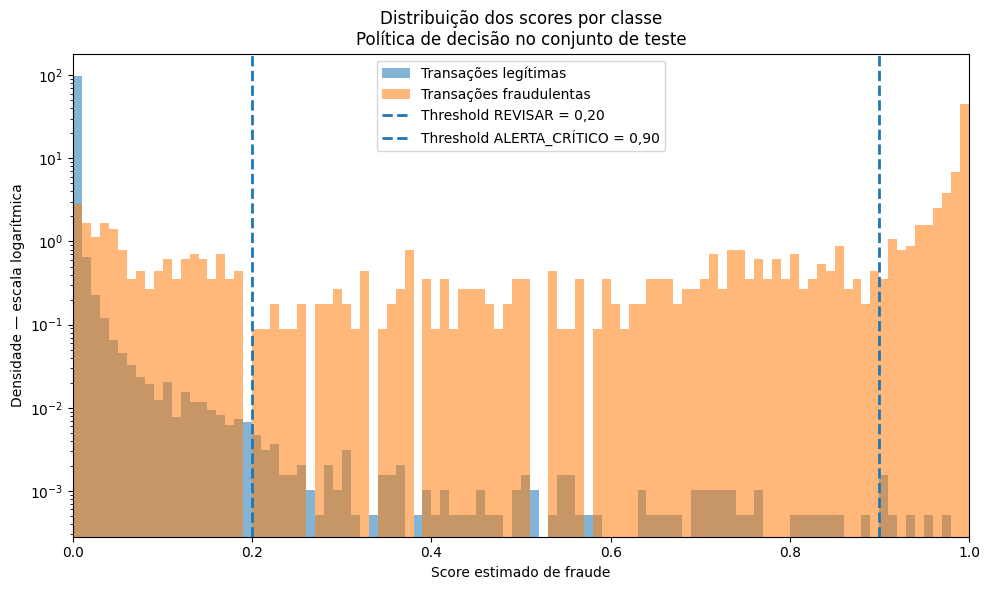

Figura salva em: /Users/lucassantos/Documents/ccard_fraud_ml/outputs/figures/07_avaliacao_final/03_distribuicao_scores_politica_final.png


In [60]:
bins = np.linspace(
    0,
    1,
    101
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    scores_legitimas,
    bins=bins,
    density=True,
    alpha=0.55,
    label="Transações legítimas"
)

ax.hist(
    scores_fraudes,
    bins=bins,
    density=True,
    alpha=0.55,
    label="Transações fraudulentas"
)

ax.axvline(
    x=0.20,
    linestyle="--",
    linewidth=2,
    label="Threshold REVISAR = 0,20"
)

ax.axvline(
    x=0.90,
    linestyle="--",
    linewidth=2,
    label="Threshold ALERTA_CRÍTICO = 0,90"
)

ax.set_yscale(
    "log"
)

ax.set_title(
    "Distribuição dos scores por classe\n"
    "Política de decisão no conjunto de teste"
)

ax.set_xlabel(
    "Score estimado de fraude"
)

ax.set_ylabel(
    "Densidade — escala logarítmica"
)

ax.set_xlim(
    0,
    1
)

ax.legend()

salvar_figura(
    fig,
    "03_distribuicao_scores_politica_final"
)